<a href="https://colab.research.google.com/github/Dinithiii04/AgriLak/blob/yield-component-cleanup/notebooks/NEW_regression_dnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paddy Yield Forecasting - Data Pre-processing & Model Implementation




## Preprocessing Yield Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# Load the dataset
file_path = '/content/drive/MyDrive/NEW_yield_data.csv'

maha_yield = pd.read_csv(file_path)

In [5]:
# Display the first few rows to verify
display(maha_yield.head(10))


,District,Year,Yield,Cultivation_Season
0,PUTTALAM,1984,2158,1983-1984
1,MONARAGALA,1984,3074,1983-1984
2,JAFFNA,1984,1255,1983-1984
3,VAVUNIYA,1984,1992,1983-1984
4,MULLATIVU,1984,1153,1983-1984
5,MANNAR,1984,3644,1983-1984
6,ANURADHAPURA,1984,3144,1983-1984
7,POLONNARUWA,1984,3785,1983-1984
8,TRINCOMALEE,1984,2365,1983-1984
9,BATTICALOA,1984,2089,1983-1984


In [6]:
maha_yield.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   District            384 non-null    object
 1   Year                384 non-null    int64 
 2   Yield               384 non-null    int64 
 3   Cultivation_Season  384 non-null    object
dtypes: int64(2), object(2)
memory usage: 12.1+ KB


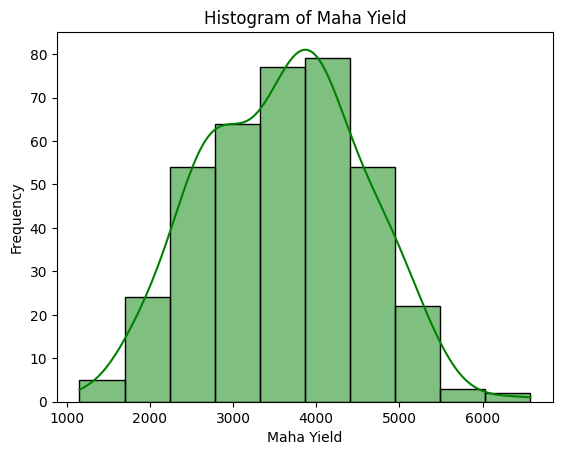

In [7]:
# Histogram of Maha yield
sns.histplot(maha_yield['Yield'], kde=True, bins=10, color='green')
plt.title('Histogram of Maha Yield')
plt.xlabel('Maha Yield')
plt.ylabel('Frequency')
plt.show()



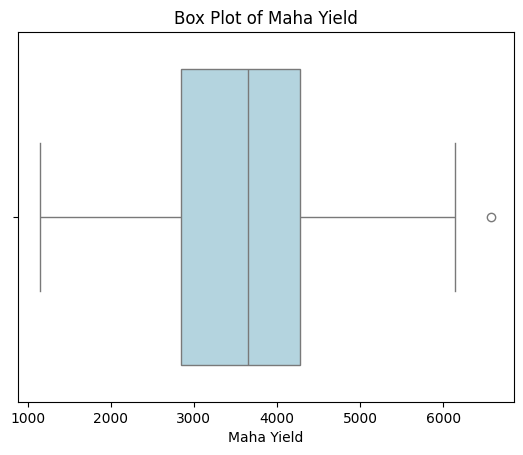

In [8]:
# Box Plot of Maha Yield
sns.boxplot(x=maha_yield['Yield'], color='lightblue')
plt.title('Box Plot of Maha Yield')
plt.xlabel('Maha Yield')
plt.show()

## Preprocessing Weather Dataset

In [9]:
file_path = '/content/drive/MyDrive/NEW_monthly_weather_data.csv'

# Load the dataset
weather_data = pd.read_csv(file_path)
weather_data.head()


,Year,Month,District,Tmax,SRAD,RH,Rain
0,1984,1,BATTICALOA,27.56,12.71,85.08,331.78
1,1984,1,JAFFNA,27.17,13.10,84.14,192.61
2,1984,1,MANNAR,27.97,14.18,87.13,254.00
3,1984,1,MONARAGALA,27.58,13.96,92.02,279.90
4,1984,1,MULLATIVU,26.89,13.10,84.98,266.93


### Handling Missing Values

In [10]:
# Select only numeric columns
numeric_columns = weather_data.select_dtypes(include=['number'])

# Check for missing values in numeric columns
missing_values_numeric = numeric_columns.isnull().sum()
print("Missing Values:\n", missing_values_numeric, "\n")

# Check for negative values in numeric columns
negative_values_numeric = (numeric_columns < 0).sum()
print("Negative Values:\n", negative_values_numeric)


Missing Values:
 Year     0
Month    0
Tmax     0
SRAD     0
RH       0
Rain     0
dtype: int64 

Negative Values:
 Year     0
Month    0
Tmax     0
SRAD     0
RH       0
Rain     0
dtype: int64


### Determine Relevant Months for Maha Season

The Maha season in Sri Lanka spans from **September to March** in the following year, roughly covering **Standard Meteorological Weeks (SMWs) 36 to 13**, which crosses over two calendar years. This aligns with the North-East Monsoon and represents one of the two main paddy cultivation seasons in Sri Lanka, as defined by the *Department of Census and Statistics in Sri Lanka*.

### Filter Data for the Maha Season

In [11]:
# Define Maha season months
maha_months_full = [8, 9, 10, 11, 12]

maha_season_data = weather_data[
    (
        ((weather_data['Month'].isin([8, 9, 10, 11, 12])) & (weather_data['Year'] == 1984)) |
        ((weather_data['Month'].isin(maha_months_full)) & (weather_data['Year'] > 1984) & (weather_data['Year'] < 2015))
    )
]

# Display the filtered dataset
display(maha_season_data)


,Year,Month,District,Tmax,SRAD,RH,Rain
84,1984,8,BATTICALOA,32.13,19.53,72.28,53.23
85,1984,8,JAFFNA,30.79,21.48,76.33,23.38
86,1984,8,MANNAR,31.07,21.30,78.19,14.91
87,1984,8,MONARAGALA,33.08,19.79,72.44,38.25
88,1984,8,MULLATIVU,31.27,21.48,77.58,30.63
...,...,...,...,...,...,...,...
4459,2014,12,TRINCOMALEE,28.30,11.78,88.11,671.55
4460,2014,12,VAVUNIYA,28.73,11.07,90.79,505.92
4461,2014,12,HAMBANTOTA,28.72,13.51,86.73,707.49
4462,2014,12,AMPARA,28.30,10.78,87.59,866.01


In [12]:
maha_season_data = maha_season_data.copy()

In [13]:
# Assign Cultivation Season based on months
maha_season_data['Cultivation_Season'] = np.where(
    maha_season_data['Month'] >= 8,
    maha_season_data['Year'].astype(str) + '-' + (maha_season_data['Year'] + 1).astype(str),
    (maha_season_data['Year'] - 1).astype(str) + '-' + maha_season_data['Year'].astype(str)
)

cols = list(maha_season_data.columns)
cols.insert(1, cols.pop(cols.index('Cultivation_Season')))

# Apply new column order
maha_season_data = maha_season_data[cols]

# Display modified dataframe
display(maha_season_data.head(20))


,Year,Cultivation_Season,Month,District,Tmax,SRAD,RH,Rain
84,1984,1984-1985,8,BATTICALOA,32.13,19.53,72.28,53.23
85,1984,1984-1985,8,JAFFNA,30.79,21.48,76.33,23.38
86,1984,1984-1985,8,MANNAR,31.07,21.30,78.19,14.91
87,1984,1984-1985,8,MONARAGALA,33.08,19.79,72.44,38.25
88,1984,1984-1985,8,MULLATIVU,31.27,21.48,77.58,30.63
89,1984,1984-1985,8,POLONNARUWA,33.45,19.53,77.00,54.60
90,1984,1984-1985,8,PUTTALAM,30.67,21.30,83.33,15.56
91,1984,1984-1985,8,TRINCOMALEE,32.42,19.40,79.22,73.03
92,1984,1984-1985,8,VAVUNIYA,33.33,21.48,78.44,31.83
93,1984,1984-1985,8,HAMBANTOTA,29.04,19.79,84.41,45.28


## Merge Weather and Yield Data

In [14]:
maha_season_data = maha_season_data.drop(columns=['Year'])

# Merge the weather data with the yield data
merged_data = maha_season_data.merge(
    maha_yield,
    on=['District', 'Cultivation_Season'],
    how='inner'
)

display(merged_data.head(20))


,Cultivation_Season,Month,District,Tmax,SRAD,RH,Rain,Year,Yield
0,1984-1985,8,BATTICALOA,32.13,19.53,72.28,53.23,1985,3163
1,1984-1985,8,JAFFNA,30.79,21.48,76.33,23.38,1985,1687
2,1984-1985,8,MANNAR,31.07,21.30,78.19,14.91,1985,3781
3,1984-1985,8,MONARAGALA,33.08,19.79,72.44,38.25,1985,2988
4,1984-1985,8,MULLATIVU,31.27,21.48,77.58,30.63,1985,2579
5,1984-1985,8,POLONNARUWA,33.45,19.53,77.00,54.60,1985,4874
6,1984-1985,8,PUTTALAM,30.67,21.30,83.33,15.56,1985,2643
7,1984-1985,8,TRINCOMALEE,32.42,19.40,79.22,73.03,1985,3379
8,1984-1985,8,VAVUNIYA,33.33,21.48,78.44,31.83,1985,2946
9,1984-1985,8,HAMBANTOTA,29.04,19.79,84.41,45.28,1985,4328


In [17]:
# Weather variables and month names in seasonal order
weather_variables = ['Tmax', 'Rain', 'SRAD', 'RH']
month_names = ['Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_name_map = dict(zip([8, 9, 10, 11, 12, 1, 2], month_names))


In [18]:
# Create a copy of the data
pivot_data = merged_data.copy()

# Extract the yield year from the Cultivation_Season
pivot_data['Year'] = pivot_data['Cultivation_Season'].apply(lambda x: int(x.split('-')[1]))

# Pivot to wide format with month-specific columns
pivot_data = pivot_data.pivot_table(
    index=['Cultivation_Season', 'District', 'Year', 'Yield'],
    columns='Month',
    values=weather_variables,
    aggfunc='first'
)

# Flatten MultiIndex columns
pivot_data.columns = [f"{month_name_map[month]}_{var}" for var, month in pivot_data.columns]

# Reset index to keep 'Year' as a regular column
pivot_data = pivot_data.reset_index()

# Ensure the correct seasonal column order
ordered_columns = (
    ['Cultivation_Season', 'District', 'Year', 'Yield'] +
    [f"{month}_{var}" for month in month_names for var in weather_variables]
)

# Reorder the DataFrame columns
pivot_data = pivot_data[ordered_columns]

# Display the restructured DataFrame
display(pivot_data.head(20))


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Rain,Aug_SRAD,Aug_RH,Sep_Tmax,Sep_Rain,...,Oct_SRAD,Oct_RH,Nov_Tmax,Nov_Rain,Nov_SRAD,Nov_RH,Dec_Tmax,Dec_Rain,Dec_SRAD,Dec_RH
0,1984-1985,AMPARA,1985,3827,32.13,53.23,19.53,72.28,33.00,228.09,...,18.66,76.50,28.71,294.75,16.61,83.00,28.19,76.80,15.23,82.81
1,1984-1985,ANURADHAPURA,1985,3972,34.34,32.92,21.48,79.94,35.49,329.77,...,18.02,85.28,30.03,278.85,17.14,88.92,29.50,85.09,15.33,87.58
2,1984-1985,BATTICALOA,1985,3163,32.13,53.23,19.53,72.28,33.00,228.09,...,18.66,76.50,28.71,294.75,16.61,83.00,28.19,76.80,15.23,82.81
3,1984-1985,HAMBANTOTA,1985,4328,29.04,45.28,19.79,84.41,29.40,175.33,...,18.61,83.41,28.33,327.30,17.65,81.97,28.24,49.10,16.66,82.28
4,1984-1985,JAFFNA,1985,1687,30.79,23.38,21.48,76.33,30.54,233.21,...,17.76,79.45,28.77,226.04,15.47,81.68,27.82,94.21,13.99,79.70
5,1984-1985,MANNAR,1985,3781,31.07,14.91,21.30,78.19,31.28,250.99,...,18.62,81.69,29.19,256.05,16.57,84.00,28.43,87.11,15.75,82.49
6,1984-1985,MONARAGALA,1985,2988,33.08,38.25,19.79,72.44,34.37,170.26,...,18.61,80.14,28.56,237.55,17.65,88.76,29.15,52.62,16.66,88.40
7,1984-1985,MULLATIVU,1985,2579,31.27,30.63,21.48,77.58,31.51,294.18,...,17.76,80.73,28.90,262.20,15.47,82.82,27.69,104.56,13.99,80.46
8,1984-1985,POLONNARUWA,1985,4874,33.45,54.60,19.53,77.00,35.05,301.86,...,18.66,83.97,30.11,303.79,16.61,86.68,29.84,95.29,15.23,85.72
9,1984-1985,PUTTALAM,1985,2643,30.67,15.56,21.30,83.33,31.54,217.87,...,18.62,82.81,29.74,286.65,16.57,85.44,29.67,53.05,15.75,84.33


### Handling outliers

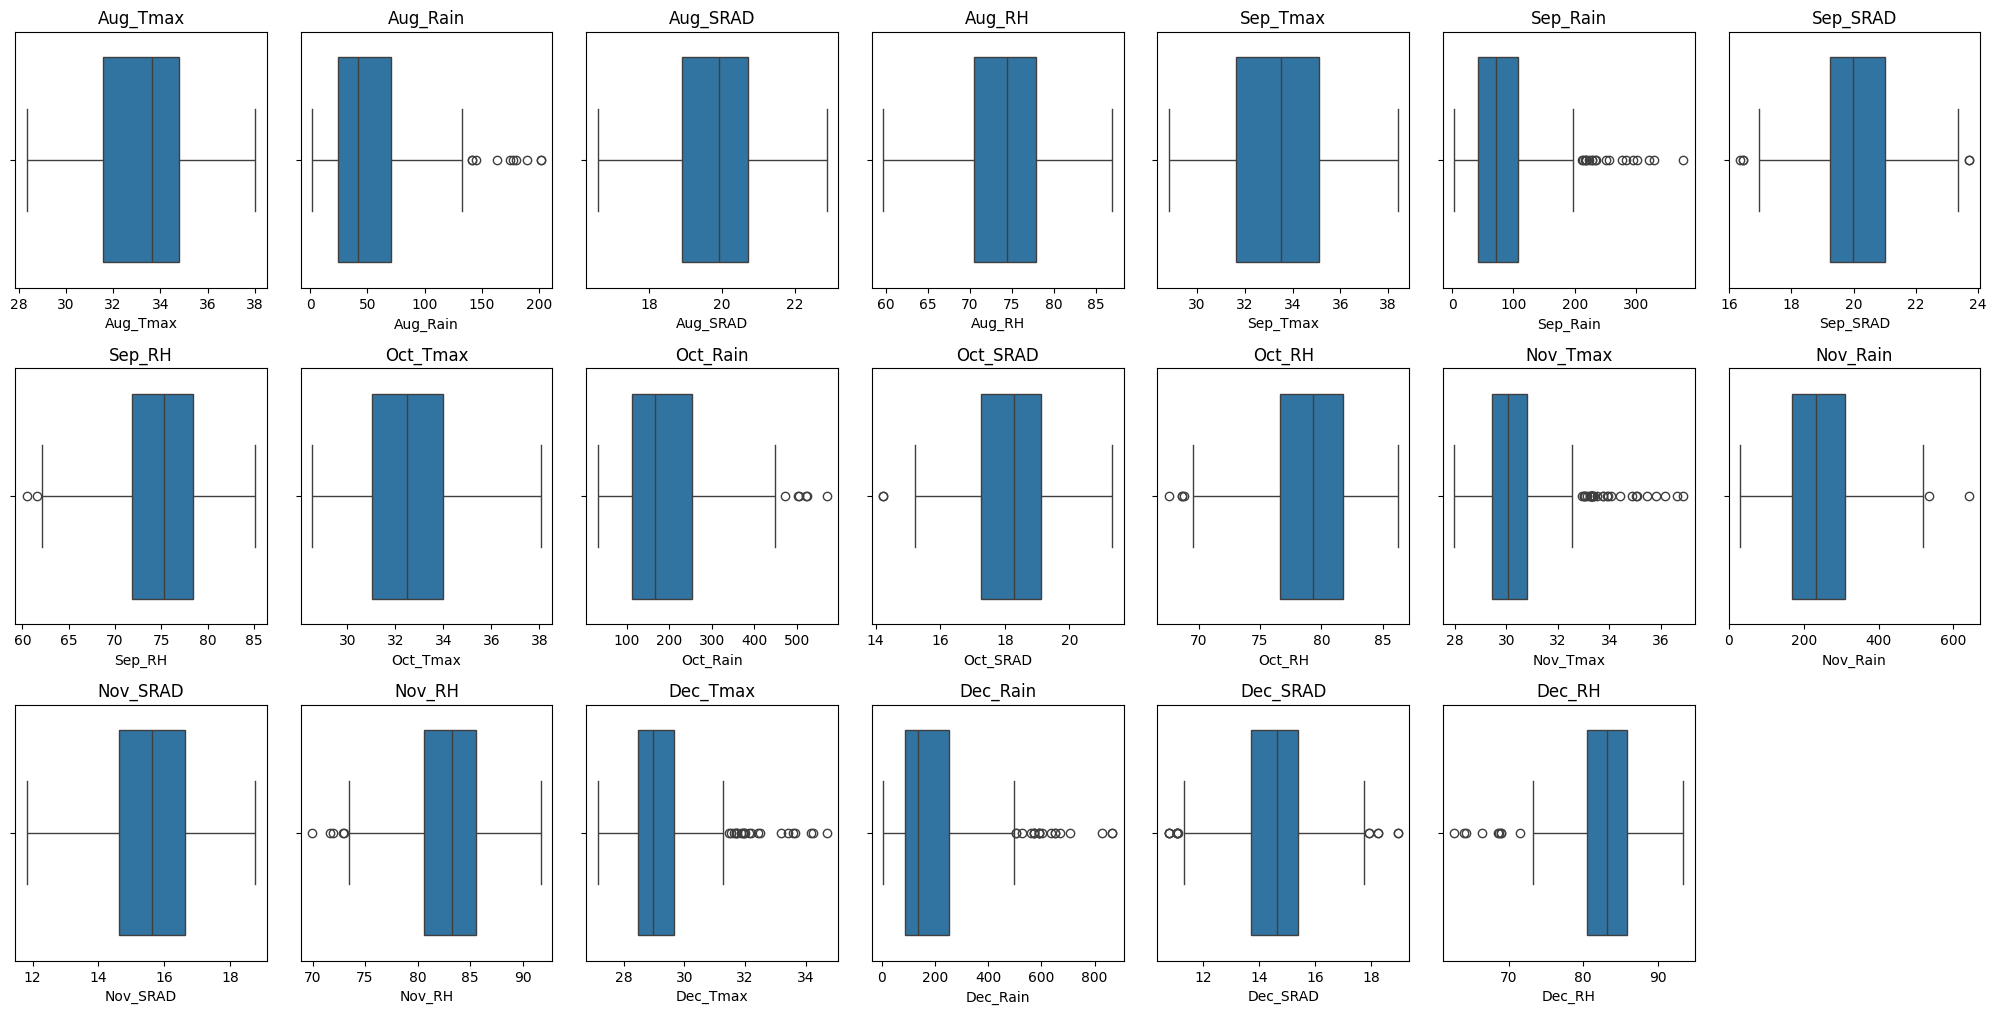

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all weather variables excluding non-numeric columns
weather_columns = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]

# Generate horizontal box plots for each weather variable
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_columns, start=1):
    plt.subplot(9, 7, i)
    sns.boxplot(x=pivot_data[variable])
    plt.title(f'{variable}')
    plt.xlabel(variable)

plt.tight_layout()
plt.show()


In [20]:
# Function to detect and print outliers based on IQR
def print_outlier_rows(df, columns):
    for variable in columns:
        Q1 = df[variable].quantile(0.25)  # First quartile
        Q3 = df[variable].quantile(0.75)  # Third quartile
        IQR = Q3 - Q1  # Interquartile range

        # Define outlier range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Get rows containing outliers
        outlier_rows = df[(df[variable] < lower_bound) | (df[variable] > upper_bound)]

        # Print results
        if not outlier_rows.empty:
            print(f"\n=== Outliers for {variable} ===")
            display(outlier_rows)
        else:
            print(f"\nNo outliers detected for {variable}")

pd.set_option("display.max_columns", None)

# Call the function on your dataset
print_outlier_rows(pivot_data, weather_columns)



No outliers detected for Aug_Tmax

=== Outliers for Aug_Rain ===


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Rain,Aug_SRAD,Aug_RH,Sep_Tmax,Sep_Rain,Sep_SRAD,Sep_RH,Oct_Tmax,Oct_Rain,Oct_SRAD,Oct_RH,Nov_Tmax,Nov_Rain,Nov_SRAD,Nov_RH,Dec_Tmax,Dec_Rain,Dec_SRAD,Dec_RH
27,1986-1987,HAMBANTOTA,1987,4302,29.48,141.10,19.05,81.41,29.45,106.05,19.17,82.30,29.10,299.62,18.95,82.71,28.96,157.48,18.20,79.78,28.72,137.66,16.86,83.61
39,1987-1988,HAMBANTOTA,1988,4853,30.05,188.82,17.67,80.21,30.71,166.24,19.22,80.85,29.07,346.53,17.59,84.54,29.22,229.09,17.31,82.40,29.76,82.01,17.04,81.38
82,1990-1991,TRINCOMALEE,1991,3421,33.49,144.42,16.59,73.81,33.21,43.20,18.66,73.34,34.10,153.57,18.34,77.41,31.23,48.04,16.52,79.67,29.64,73.74,13.59,80.18
267,2006-2007,HAMBANTOTA,2007,5215,30.18,141.49,20.62,83.52,29.19,216.64,19.23,83.53,29.22,392.16,18.37,83.89,28.43,396.47,16.44,85.48,28.45,330.26,12.59,84.85
279,2007-2008,HAMBANTOTA,2008,4762,29.45,162.94,20.69,83.04,29.10,192.24,19.30,84.31,29.65,327.32,17.71,85.11,29.97,205.86,18.73,81.15,28.52,238.95,14.61,84.01
303,2009-2010,HAMBANTOTA,2010,5183,29.82,174.38,20.30,83.55,29.73,143.90,21.34,83.01,29.64,182.73,20.31,80.37,29.74,536.11,14.24,83.46,28.79,238.32,14.67,85.33
315,2010-2011,HAMBANTOTA,2011,5779,28.91,201.22,20.24,85.21,29.35,256.19,19.28,85.14,29.20,213.45,20.41,83.09,28.95,641.30,16.28,83.11,28.27,483.26,14.59,84.65
327,2011-2012,HAMBANTOTA,2012,5198,28.89,179.72,20.40,84.68,29.57,161.69,21.70,83.54,29.41,268.51,19.31,82.91,28.92,319.30,16.08,82.70,28.88,193.23,14.73,82.45
339,2012-2013,HAMBANTOTA,2013,6575,29.55,177.38,20.61,82.90,29.15,234.25,20.51,83.12,28.89,446.70,18.94,83.91,29.30,361.09,16.71,82.29,28.11,496.24,14.82,85.75
363,2014-2015,HAMBANTOTA,2015,6134,29.65,201.38,20.39,83.01,29.16,196.29,21.13,83.25,29.01,525.11,19.25,83.48,29.84,375.87,15.19,84.22,28.72,707.49,13.51,86.73



No outliers detected for Aug_SRAD

No outliers detected for Aug_RH

No outliers detected for Sep_Tmax

=== Outliers for Sep_Rain ===


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Rain,Aug_SRAD,Aug_RH,Sep_Tmax,Sep_Rain,Sep_SRAD,Sep_RH,Oct_Tmax,Oct_Rain,Oct_SRAD,Oct_RH,Nov_Tmax,Nov_Rain,Nov_SRAD,Nov_RH,Dec_Tmax,Dec_Rain,Dec_SRAD,Dec_RH
0,1984-1985,AMPARA,1985,3827,32.13,53.23,19.53,72.28,33.00,228.09,19.81,71.84,31.03,151.14,18.66,76.50,28.71,294.75,16.61,83.00,28.19,76.80,15.23,82.81
1,1984-1985,ANURADHAPURA,1985,3972,34.34,32.92,21.48,79.94,35.49,329.77,17.28,78.64,30.75,115.19,18.02,85.28,30.03,278.85,17.14,88.92,29.50,85.09,15.33,87.58
2,1984-1985,BATTICALOA,1985,3163,32.13,53.23,19.53,72.28,33.00,228.09,19.81,71.84,31.03,151.14,18.66,76.50,28.71,294.75,16.61,83.00,28.19,76.80,15.23,82.81
4,1984-1985,JAFFNA,1985,1687,30.79,23.38,21.48,76.33,30.54,233.21,19.14,77.73,29.12,101.59,17.76,79.45,28.77,226.04,15.47,81.68,27.82,94.21,13.99,79.70
5,1984-1985,MANNAR,1985,3781,31.07,14.91,21.30,78.19,31.28,250.99,20.31,79.26,29.41,91.90,18.62,81.69,29.19,256.05,16.57,84.00,28.43,87.11,15.75,82.49
7,1984-1985,MULLATIVU,1985,2579,31.27,30.63,21.48,77.58,31.51,294.18,19.14,77.84,29.60,103.23,17.76,80.73,28.90,262.20,15.47,82.82,27.69,104.56,13.99,80.46
8,1984-1985,POLONNARUWA,1985,4874,33.45,54.60,19.53,77.00,35.05,301.86,19.81,76.73,30.90,113.58,18.66,83.97,30.11,303.79,16.61,86.68,29.84,95.29,15.23,85.72
9,1984-1985,PUTTALAM,1985,2643,30.67,15.56,21.30,83.33,31.54,217.87,20.31,80.24,29.96,146.78,18.62,82.81,29.74,286.65,16.57,85.44,29.67,53.05,15.75,84.33
10,1984-1985,TRINCOMALEE,1985,3379,32.42,73.03,19.40,79.22,32.71,376.98,18.67,77.93,30.36,102.69,18.40,82.20,29.31,286.11,16.14,84.56,28.38,119.59,14.89,82.43
11,1984-1985,VAVUNIYA,1985,2946,33.33,31.83,21.48,78.44,34.71,321.38,17.28,78.70,30.34,100.58,18.02,84.48,29.75,276.39,17.14,86.80,29.21,97.89,15.33,84.88



=== Outliers for Sep_SRAD ===


...

,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Rain,Aug_SRAD,Aug_RH,Sep_Tmax,Sep_Rain,Sep_SRAD,Sep_RH,Oct_Tmax,Oct_Rain,Oct_SRAD,Oct_RH,Nov_Tmax,Nov_Rain,Nov_SRAD,Nov_RH,Dec_Tmax,Dec_Rain,Dec_SRAD,Dec_RH
312,2010-2011,AMPARA,2011,3333,34.01,110.11,19.99,72.28,33.70,144.85,19.76,74.98,32.17,158.83,20.04,77.57,30.33,519.15,15.51,82.93,28.86,574.49,12.05,84.64
314,2010-2011,BATTICALOA,2011,2399,34.01,110.11,19.99,72.28,33.70,144.85,19.76,74.98,32.17,158.83,20.04,77.57,30.33,519.15,15.51,82.93,28.86,574.49,12.05,84.64
318,2010-2011,MONARAGALA,2011,4077,32.54,90.68,20.24,76.54,33.30,135.95,19.28,77.80,32.93,154.32,20.41,81.61,29.80,511.10,16.28,88.31,28.53,505.81,14.59,91.66
320,2010-2011,POLONNARUWA,2011,3831,35.25,132.48,19.99,75.96,34.11,184.13,19.76,79.59,32.50,149.67,20.04,83.54,30.55,461.78,15.51,87.16,29.21,591.11,12.05,90.04
322,2010-2011,TRINCOMALEE,2011,2388,34.10,120.40,18.86,76.49,33.20,218.45,19.22,78.26,31.61,112.63,19.06,82.46,29.95,382.90,14.80,84.02,28.79,600.93,11.10,86.07
336,2012-2013,AMPARA,2013,4084,34.53,33.06,20.94,69.18,34.15,83.24,20.78,72.27,32.69,347.28,18.23,80.24,29.76,288.97,16.27,81.71,28.31,593.23,13.31,83.94
337,2012-2013,ANURADHAPURA,2013,4467,37.06,8.67,20.80,67.00,37.39,59.05,19.39,68.88,37.01,522.41,16.80,83.27,31.25,214.80,15.96,88.22,29.72,559.96,12.67,90.27
338,2012-2013,BATTICALOA,2013,2088,34.53,33.06,20.94,69.18,34.15,83.24,20.78,72.27,32.69,347.28,18.23,80.24,29.76,288.97,16.27,81.71,28.31,593.23,13.31,83.94
344,2012-2013,POLONNARUWA,2013,4889,37.51,21.91,20.94,66.35,36.48,85.00,20.78,69.11,37.10,472.24,18.23,80.67,31.05,275.94,16.27,85.69,29.52,638.25,13.31,88.42
346,2012-2013,TRINCOMALEE,2013,3424,34.87,11.94,20.86,69.47,34.87,107.60,20.27,71.40,34.87,570.32,18.32,80.70,30.29,244.20,16.33,82.54,28.56,650.60,14.15,83.60



=== Outliers for Dec_SRAD ===


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Rain,Aug_SRAD,Aug_RH,Sep_Tmax,Sep_Rain,Sep_SRAD,Sep_RH,Oct_Tmax,Oct_Rain,Oct_SRAD,Oct_RH,Nov_Tmax,Nov_Rain,Nov_SRAD,Nov_RH,Dec_Tmax,Dec_Rain,Dec_SRAD,Dec_RH
183,1999-2000,HAMBANTOTA,2000,4354,29.12,71.06,21.70,82.60,30.01,104.08,20.50,82.19,29.19,177.86,17.52,84.53,30.00,188.97,17.01,83.08,29.67,115.71,17.91,80.43
186,1999-2000,MONARAGALA,2000,3984,34.94,40.12,21.70,67.51,34.89,77.81,20.50,68.75,32.24,165.72,17.52,81.37,32.56,168.89,17.01,86.58,28.49,92.26,17.91,87.94
231,2003-2004,HAMBANTOTA,2004,4627,30.16,68.67,20.47,82.75,30.15,67.53,21.71,82.66,30.53,131.78,20.89,79.76,29.61,350.63,14.36,85.66,29.20,35.33,18.94,80.77
233,2003-2004,MANNAR,2004,4102,31.67,34.91,20.68,78.90,32.82,32.32,23.27,76.68,32.42,122.03,20.00,79.00,30.89,308.03,14.89,83.84,29.56,29.30,18.24,80.58
234,2003-2004,MONARAGALA,2004,4064,35.26,30.89,20.47,68.88,36.75,33.42,21.71,63.21,36.11,97.30,20.89,72.41,30.60,295.63,14.36,89.81,29.30,34.43,18.94,86.73
237,2003-2004,PUTTALAM,2004,3685,31.88,38.99,20.68,80.40,33.13,42.07,23.27,77.45,33.08,143.95,20.00,79.78,32.37,188.52,14.89,83.49,31.86,32.38,18.24,79.82
313,2010-2011,ANURADHAPURA,2011,4463,35.62,102.56,18.02,75.57,35.03,212.75,18.50,78.75,31.58,122.66,18.33,85.79,30.57,373.30,14.42,88.81,29.26,429.14,11.08,91.71
322,2010-2011,TRINCOMALEE,2011,2388,34.10,120.40,18.86,76.49,33.20,218.45,19.22,78.26,31.61,112.63,19.06,82.46,29.95,382.90,14.80,84.02,28.79,600.93,11.10,86.07
323,2010-2011,VAVUNIYA,2011,4139,34.99,96.93,18.02,74.75,33.69,197.12,18.50,78.06,31.93,121.47,18.33,84.79,30.66,412.31,14.42,86.42,29.29,450.15,11.08,89.59
360,2014-2015,AMPARA,2015,4078,33.78,79.60,20.45,70.27,35.08,81.50,20.92,71.91,32.81,334.32,18.55,79.28,29.93,403.13,13.67,82.52,28.30,866.01,10.78,87.59



=== Outliers for Dec_RH ===


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Rain,Aug_SRAD,Aug_RH,Sep_Tmax,Sep_Rain,Sep_SRAD,Sep_RH,Oct_Tmax,Oct_Rain,Oct_SRAD,Oct_RH,Nov_Tmax,Nov_Rain,Nov_SRAD,Nov_RH,Dec_Tmax,Dec_Rain,Dec_SRAD,Dec_RH
133,1995-1996,ANURADHAPURA,1996,3700,37.90,3.43,19.50,67.13,37.77,6.16,19.74,67.89,36.33,63.06,17.41,72.85,35.82,31.83,15.09,73.01,33.63,14.48,16.13,62.75
136,1995-1996,JAFFNA,1996,2062,31.21,22.27,20.43,77.42,31.62,25.26,19.77,78.19,30.94,81.89,16.88,79.51,30.18,63.74,14.50,75.51,28.92,11.56,14.97,68.97
137,1995-1996,MANNAR,1996,3094,31.92,7.15,20.37,76.74,32.15,11.45,21.08,77.42,32.26,64.51,18.79,78.15,31.74,40.45,15.72,74.95,30.79,10.41,16.35,66.47
138,1995-1996,MONARAGALA,1996,3228,36.70,10.55,18.00,59.71,37.78,8.32,18.59,60.45,36.47,32.17,16.13,67.57,35.09,46.46,15.30,75.01,32.00,18.42,15.74,71.50
139,1995-1996,MULLATIVU,1996,2578,32.30,20.74,20.43,75.05,32.96,18.20,19.77,75.59,32.52,77.40,16.88,78.50,30.72,45.24,14.50,75.82,28.81,12.81,14.97,68.61
140,1995-1996,POLONNARUWA,1996,4833,38.03,10.72,19.15,64.07,37.65,5.16,19.27,64.45,36.36,58.01,16.88,70.96,35.48,72.71,15.19,73.50,31.27,26.73,14.09,68.66
141,1995-1996,PUTTALAM,1996,3429,32.82,15.69,20.37,76.94,32.73,19.02,21.08,77.03,34.27,71.13,18.79,77.32,33.26,82.48,15.72,75.99,33.41,6.83,16.35,63.98
142,1995-1996,TRINCOMALEE,1996,2939,35.56,6.41,18.49,69.59,34.86,3.89,18.56,69.92,33.47,56.76,16.52,74.71,33.51,51.94,14.67,74.45,29.51,21.78,14.32,68.96
143,1995-1996,VAVUNIYA,1996,2212,36.04,6.94,19.50,68.95,36.12,6.92,19.74,69.75,36.11,65.24,17.41,74.52,33.92,30.01,15.09,74.00,31.69,13.46,16.13,64.32


### Correlation of Weather Variables with Final Yield

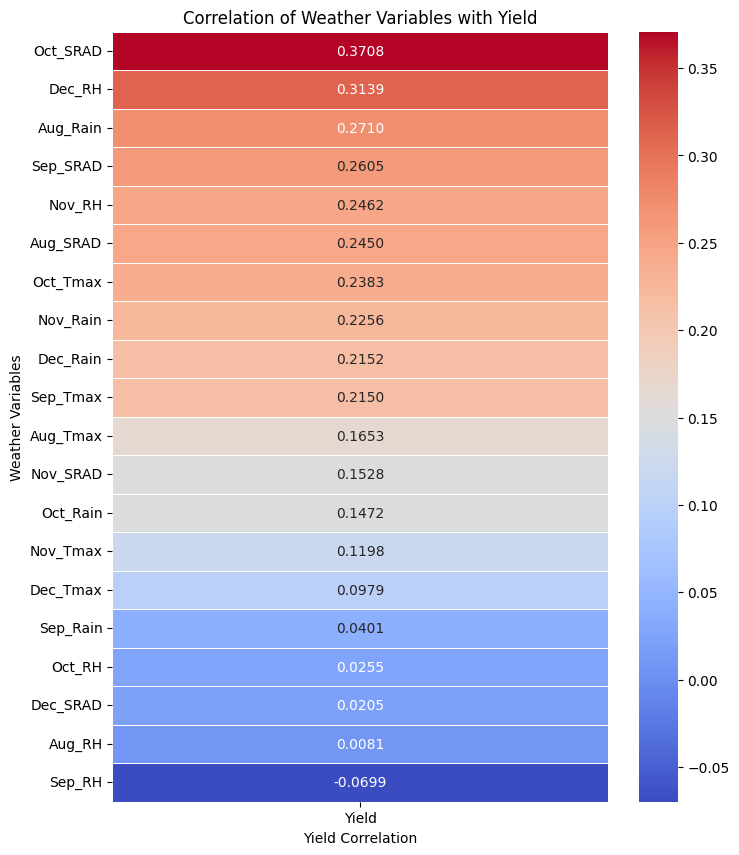

In [21]:
# Calculate the correlation of all weather variables with Yield
correlation_df = pivot_data[weather_columns + ['Yield']].corr()['Yield'].drop('Yield').sort_values(ascending=False)

# Convert to DataFrame for heatmap
correlation_matrix = correlation_df.to_frame()

# Plot the heatmap
plt.figure(figsize=(8, len(correlation_df) * 0.5))  # Adjust size based on number of variables
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, cbar=True)

# Titles and labels
plt.title("Correlation of Weather Variables with Yield")
plt.xlabel("Yield Correlation")
plt.ylabel("Weather Variables")

# Show the plot
plt.show()

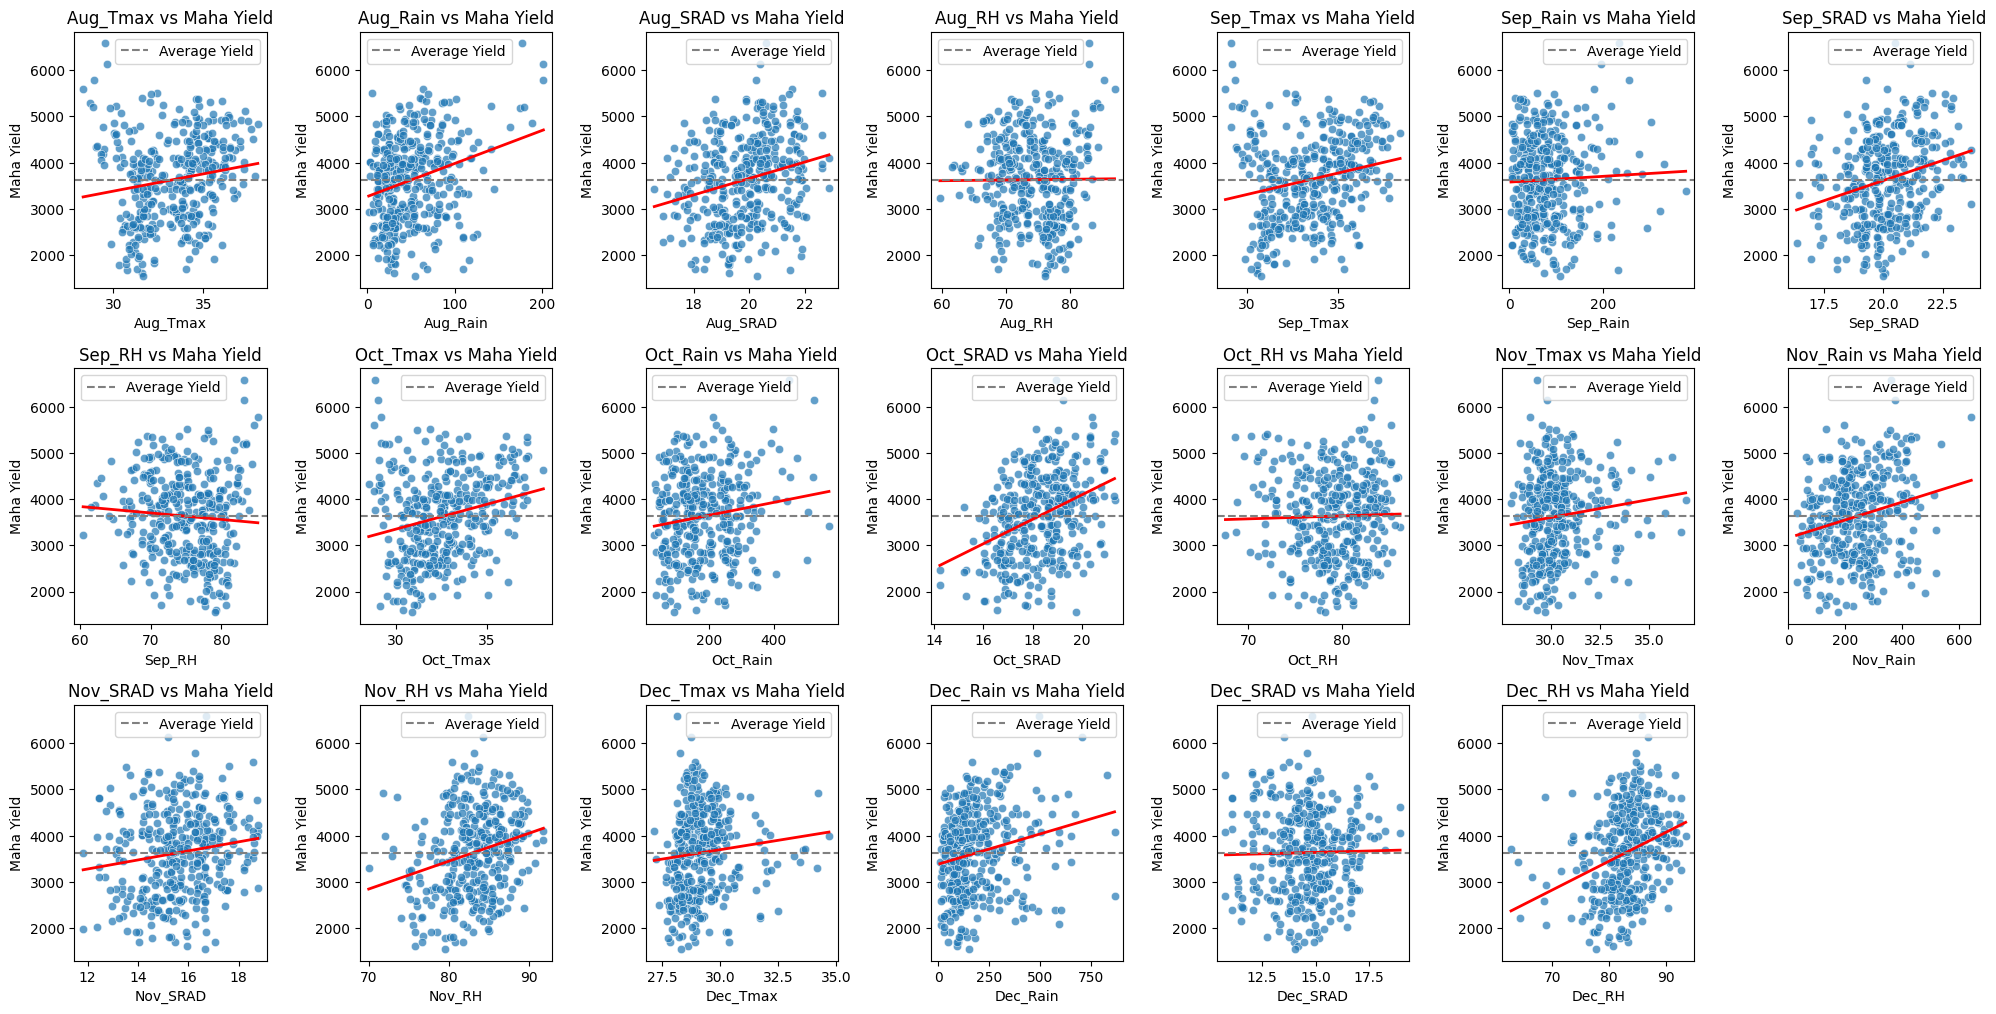

In [22]:
# Select all weather variables excluding non-numeric columns
weather_columns = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]

# Generate scatter plots with trend lines for each weather variable against Maha_Yield
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_columns, start=1):
    plt.subplot(9, 7, i)
    sns.scatterplot(x=pivot_data[variable], y=pivot_data['Yield'], alpha=0.7)
    sns.regplot(x=pivot_data[variable], y=pivot_data['Yield'], scatter=False, ci=None, color='red', line_kws={"linewidth": 2})
    plt.title(f'{variable} vs Maha Yield')
    plt.xlabel(variable)
    plt.ylabel('Maha Yield')
    plt.axhline(y=pivot_data['Yield'].mean(), color='gray', linestyle='--', label='Average Yield')
    plt.legend()

plt.tight_layout()
plt.show()


In [23]:
# Drop the first three columns and create the final DataFrame
final_df = pivot_data.drop(columns=['Cultivation_Season', 'District', 'Year'])

# Display the first 20 rows of the final DataFrame
display(final_df.head())

,Yield,Aug_Tmax,Aug_Rain,Aug_SRAD,Aug_RH,Sep_Tmax,Sep_Rain,Sep_SRAD,Sep_RH,Oct_Tmax,Oct_Rain,Oct_SRAD,Oct_RH,Nov_Tmax,Nov_Rain,Nov_SRAD,Nov_RH,Dec_Tmax,Dec_Rain,Dec_SRAD,Dec_RH
0,3827,32.13,53.23,19.53,72.28,33.00,228.09,19.81,71.84,31.03,151.14,18.66,76.50,28.71,294.75,16.61,83.00,28.19,76.80,15.23,82.81
1,3972,34.34,32.92,21.48,79.94,35.49,329.77,17.28,78.64,30.75,115.19,18.02,85.28,30.03,278.85,17.14,88.92,29.50,85.09,15.33,87.58
2,3163,32.13,53.23,19.53,72.28,33.00,228.09,19.81,71.84,31.03,151.14,18.66,76.50,28.71,294.75,16.61,83.00,28.19,76.80,15.23,82.81
3,4328,29.04,45.28,19.79,84.41,29.40,175.33,19.80,80.97,28.53,209.60,18.61,83.41,28.33,327.30,17.65,81.97,28.24,49.10,16.66,82.28
4,1687,30.79,23.38,21.48,76.33,30.54,233.21,19.14,77.73,29.12,101.59,17.76,79.45,28.77,226.04,15.47,81.68,27.82,94.21,13.99,79.70


In [24]:
final_df.to_csv('/content/FINAL_yield_pred_data.csv', index=False)

## Split Data into Train-Test Sets

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [26]:
# Load dataset
df = pd.read_csv('/content/FINAL_yield_pred_data.csv')

# Perform 80-20 random train-test split
X = df.drop(columns=["Yield"])  # Features
y = df["Yield"]  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print dataset sizes
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 297
Testing samples: 75


In [27]:
display(X_train.head())

,Aug_Tmax,Aug_Rain,Aug_SRAD,Aug_RH,Sep_Tmax,Sep_Rain,Sep_SRAD,Sep_RH,Oct_Tmax,Oct_Rain,Oct_SRAD,Oct_RH,Nov_Tmax,Nov_Rain,Nov_SRAD,Nov_RH,Dec_Tmax,Dec_Rain,Dec_SRAD,Dec_RH
192,33.61,52.89,19.41,71.45,34.16,74.91,19.89,73.75,33.84,55.68,19.80,71.00,30.66,296.07,14.15,79.31,28.65,138.39,12.33,83.52
75,30.19,39.92,17.83,79.51,30.36,34.59,19.59,78.37,30.83,238.74,17.97,80.52,29.51,157.68,17.77,82.42,29.29,172.98,15.02,83.59
84,33.30,41.94,18.90,69.48,33.66,63.19,21.58,68.74,32.82,209.49,17.10,77.42,30.05,197.71,16.81,81.58,28.05,137.74,13.83,81.46
360,33.78,79.60,20.45,70.27,35.08,81.50,20.92,71.91,32.81,334.32,18.55,79.28,29.93,403.13,13.67,82.52,28.30,866.01,10.78,87.59
16,30.31,64.38,19.26,77.51,30.57,133.07,19.28,77.73,29.85,79.77,18.21,77.79,28.37,294.84,14.56,79.48,27.74,179.70,15.13,81.91


### Scale Data

In [28]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled data back to DataFrame (optional, for readability)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Print dataset sizes
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples: {X_test_scaled.shape[0]}")

Training samples: 297
Testing samples: 75


In [29]:
display(X_train_scaled.head())

,Aug_Tmax,Aug_Rain,Aug_SRAD,Aug_RH,Sep_Tmax,Sep_Rain,Sep_SRAD,Sep_RH,Oct_Tmax,Oct_Rain,Oct_SRAD,Oct_RH,Nov_Tmax,Nov_Rain,Nov_SRAD,Nov_RH,Dec_Tmax,Dec_Rain,Dec_SRAD,Dec_RH
0,0.107861,0.084786,-0.410252,-0.552300,0.311664,-0.179935,-0.141404,-0.262207,0.610963,-1.318960,1.218708,-2.186964,0.251926,0.446469,-0.955570,-1.005357,-0.447252,-0.372190,-1.441746,0.113001
1,-1.569406,-0.289077,-1.664503,1.145059,-1.449344,-0.845957,-0.361016,0.740203,-0.865086,0.534701,-0.194038,0.380661,-0.590336,-0.841130,1.521217,-0.186585,0.172562,-0.149312,0.352811,0.127830
2,-0.044172,-0.230850,-0.815105,-0.967163,0.079952,-0.373531,1.095741,-1.349236,0.110773,0.238517,-0.865671,-0.455435,-0.194839,-0.468686,0.864390,-0.407733,-1.028329,-0.376378,-0.441064,-0.323410
3,0.191234,0.854706,0.415331,-0.800797,0.738013,-0.071079,0.612596,-0.661435,0.105870,1.502542,0.253718,0.046223,-0.282727,1.442570,-1.283984,-0.160258,-0.786214,4.316179,-2.475784,0.975230
4,-1.510555,0.415987,-0.529327,0.723878,-1.352025,0.780776,-0.587948,0.601341,-1.345660,-1.075025,-0.008760,-0.355643,-1.425274,0.435025,-0.675050,-0.960601,-1.328551,-0.106012,0.426194,-0.228077


In [33]:
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Aug_Tmax  297 non-null    float64
 1   Aug_Rain  297 non-null    float64
 2   Aug_SRAD  297 non-null    float64
 3   Aug_RH    297 non-null    float64
 4   Sep_Tmax  297 non-null    float64
 5   Sep_Rain  297 non-null    float64
 6   Sep_SRAD  297 non-null    float64
 7   Sep_RH    297 non-null    float64
 8   Oct_Tmax  297 non-null    float64
 9   Oct_Rain  297 non-null    float64
 10  Oct_SRAD  297 non-null    float64
 11  Oct_RH    297 non-null    float64
 12  Nov_Tmax  297 non-null    float64
 13  Nov_Rain  297 non-null    float64
 14  Nov_SRAD  297 non-null    float64
 15  Nov_RH    297 non-null    float64
 16  Dec_Tmax  297 non-null    float64
 17  Dec_Rain  297 non-null    float64
 18  Dec_SRAD  297 non-null    float64
 19  Dec_RH    297 non-null    float64
dtypes: float64(20)
memory usage: 46.

## Model implementation

In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the model
model = keras.Sequential([
    layers.Dense(40, activation='relu', input_shape=(X_train_scaled.shape[1],)),  # Hidden layer with 40 neurons
    layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the model architecture
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 40)                  │             840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              41 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 881 (3.44 KB)

 Trainable params: 881 (3.44 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 13488656.0000 - mae: 3539.7915 - val_loss: 14873426.0000 - val_mae: 3764.1729
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 14047996.0000 - mae: 3616.3826 - val_loss: 14870876.0000 - val_mae: 3763.8450
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13735864.0000 - mae: 3591.3953 - val_loss: 14868291.0000 - val_mae: 3763.5125
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13422187.0000 - mae: 3530.3469 - val_loss: 14865691.0000 - val_mae: 3763.1787
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 13861557.0000 - mae: 3597.1472 - val_loss: 14862909.0000 - val_mae: 3762.8203
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 14087776.0000 - mae: 3619.1853 - val_loss: 14860070.0000 - val_mae: 3762.4546
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13734328.0000 - mae: 3580.6538 - val_loss: 14857079.0000 - val_mae: 3762.0691
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9m

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on train and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Compute metrics for Training Set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Compute metrics for Test Set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Training Performance:")
print(f"Train R² Score: {train_r2:.4f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train MAE: {train_mae:.2f}")

print(f"\nTesting Performance:")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")




10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Training Performance:
Train R² Score: -14.1616
Train RMSE: 3708.87
Train MAE: 3584.95

Testing Performance:
Test R² Score: -19.9928
Test RMSE: 3846.60
Test MAE: 3754.29
